<a href="https://colab.research.google.com/github/Shivanihmm/Fake_news_classification/blob/main/Fake_news_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
pip install tensorflow

In [ ]:
pip install keras

In [ ]:
import keras
from tensorflow.python.client import device_lib

print(device_lib.list_local_devices())
import numpy as np
import pandas as pd
from collections import defaultdict
import re


import sys
import os

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical  # Updated import
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense, Input, Flatten
from tensorflow.keras.models import Sequential


from keras.layers import Embedding
from keras.layers import Dense, Input, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding, Concatenate, Dropout

from keras.models import Model

MAX_SEQUENCE_LENGTH = 1000
MAX_NB_WORDS = 200000
EMBEDDING_DIM = 100
VALIDATION_SPLIT = 0.2


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 15065916532484732504
xla_global_id: -1
]


In [ ]:
def clean_str(string):
    """
    Cleaning of dataset
    """
    string = re.sub(r"\\", "", string)
    string = re.sub(r"\'", "", string)
    string = re.sub(r"\"", "", string)
    return string.strip().lower()


In [ ]:
data_train = pd.read_csv('/content/train.csv')

In [ ]:
# Input Data preprocessing
data_train = pd.read_csv('/content/train.csv')
#print(data_train.columns)
#print('What the raw input data looks like:')
#print(data_train[0:5])
texts = []
labels = []

for i in range(data_train.text.shape[0]):
    text1 = data_train.title[i]
    text2 = data_train.text[i]
    text = str(text1) +""+ str(text2)
    texts.append(text)
    labels.append(data_train.label[i])

tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

word_index = tokenizer.word_index
#print('Found %s unique tokens.' % len(word_index))

In [ ]:
# Pad input sequences
data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)
labels = to_categorical(np.asarray(labels),num_classes = 2)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)

Shape of data tensor: (20800, 1000)
Shape of label tensor: (20800, 2)


In [ ]:
# Train test validation Split
from sklearn.model_selection import train_test_split

indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]
x_train, x_test, y_train, y_test = train_test_split( data, labels, test_size=0.20, random_state=42)
x_test, x_val, y_test, y_val = train_test_split( x_test, y_test, test_size=0.50, random_state=42)
print('Size of train, validation, test:', len(y_train), len(y_val), len(y_test))

print('real & fake news in train,valt,test:')
print(y_train.sum(axis=0))
print(y_val.sum(axis=0))
print(y_test.sum(axis=0))

Size of train, validation, test: 16640 2080 2080
real & fake news in train,valt,test:
[8337. 8303.]
[1005. 1075.]
[1045. 1035.]


In [ ]:
from keras.models import Sequential
from keras.layers import Conv3D
from keras.layers import ConvLSTM2D
from keras.layers import BatchNormalization
import numpy as np
from matplotlib import pyplot as plt
from keras.layers import Dense, Embedding, LSTM, GRU

%matplotlib inline

In [ ]:
#Using Pre-trained word embeddings
GLOVE_DIR = "data"
embeddings_index = {}
f = open(os.path.join(GLOVE_DIR, '/content/glove.6B.100d.txt'), encoding="utf8")
for line in f:
    values = line.split()
    #print(values[1:])
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Total %s word vectors in Glove.' % len(embeddings_index))

embedding_matrix = np.random.random((len(word_index) + 1, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        # words not found in embedding index will be all-zeros.
        embedding_matrix[i] = embedding_vector

embedding_layer = Embedding(len(word_index) + 1,
                            EMBEDDING_DIM,
                            weights=[embedding_matrix],
                            input_length=MAX_SEQUENCE_LENGTH)

Total 400000 word vectors in Glove.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Dropout, Conv1D, MaxPooling1D, LSTM, BatchNormalization, Dense
from tensorflow.keras.optimizers import Adam

# Define the model
embedding_vector_length = 32
model = Sequential()

# Input and Embedding layer
model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))  # Match the padded sequence length
  # Input shape explicitly defined
model.add(Embedding(input_dim=len(word_index) + 1, output_dim=embedding_vector_length))
  # Embedding layer

# Dropout for regularization
model.add(Dropout(0.2))

# 1D Convolution and MaxPooling
model.add(Conv1D(filters=32, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# Second 1D Convolution and MaxPooling
model.add(Conv1D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# LSTM layer with Dropout
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))

# Batch Normalization
model.add(BatchNormalization())

# Fully connected Dense layers
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer for binary classification
model.add(Dense(2, activation='softmax'))

# Compile the model
model.compile(
    loss='binary_crossentropy',  # Loss function for binary classification
    optimizer=Adam(),  # Adam optimizer
    metrics=['accuracy']  # Track accuracy during training
)

# Print the model summary
model.summary()

# Train the model





Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1000, 32)       │     8,060,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 32)       │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,204,962 (31.30 MB)

 Trainable params: 8,204,762 (31.30 MB)

 Non-trainable params: 200 (800.00 B)

In [ ]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val)
)


Epoch 1/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 200s 740ms/step - accuracy: 0.7707 - loss: 0.4298 - val_accuracy: 0.9361 - val_loss: 0.2577
Epoch 2/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 201s 740ms/step - accuracy: 0.9740 - loss: 0.0831 - val_accuracy: 0.9452 - val_loss: 0.1440
Epoch 3/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 202s 739ms/step - accuracy: 0.9897 - loss: 0.0331 - val_accuracy: 0.9553 - val_loss: 0.1630
Epoch 4/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 199s 728ms/step - accuracy: 0.9945 - loss: 0.0194 - val_accuracy: 0.9457 - val_loss: 0.2094
Epoch 5/5
260/260 ━━━━━━━━━━━━━━━━━━━━ 200s 721ms/step - accuracy: 0.9944 - loss: 0.0172 - val_accuracy: 0.9500 - val_loss: 0.2095


In [ ]:
model.save('lstm.h5')

In [ ]:
embedding_vecor_length = 32
modelg = Sequential()
modelg.add(embedding_layer)
modelg.add(GRU(100, dropout=0.2, recurrent_dropout=0.2))
###
modelg.add(BatchNormalization())
###
modelg.add(Dense(2, activation='softmax'))
modelg.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
modelg.fit(x_train, y_train, epochs=1, batch_size=64)
modelg.save('gru.h5')

260/260 ━━━━━━━━━━━━━━━━━━━━ 723s 3s/step - accuracy: 0.5014 - loss: nan


65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step
Correct predictions: 2001.0
Total number of test examples: 2080
Accuracy of model1:  0.9620192307692308
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step


<Axes: >

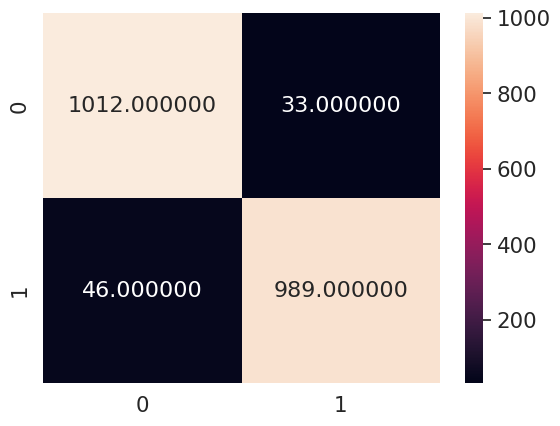

In [ ]:
# Test model 1
import matplotlib.pyplot as plt
import seaborn as sns
test_preds = model.predict(x_test)
test_preds = np.round(test_preds)
correct_predictions = float(sum(test_preds == y_test)[0])
print("Correct predictions:", correct_predictions)
print("Total number of test examples:", len(y_test))
print("Accuracy of model1: ", correct_predictions/float(len(y_test)))

# Creating the Confusion Matrix
from sklearn.metrics import confusion_matrix
x_pred = model.predict(x_test)
x_pred = np.round(x_pred)
x_pred = x_pred.argmax(1)
y_test_s = y_test.argmax(1)
cm = confusion_matrix(y_test_s, x_pred)

sns.set(font_scale=1.4)#for label size
sns.heatmap(cm,annot=True,annot_kws={"size": 16},fmt='1f')# font size


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer
import pickle
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Start Spark session
spark = SparkSession.builder \
    .appName("FakeNewsPrediction") \
    .getOrCreate()

# Function to create and save a tokenizer using Keras
def create_and_save_tokenizer(csv_file_path, text_column, tokenizer_path, vocab_path):
    try:
        # Load the CSV file into a Spark DataFrame
        df = spark.read.csv(csv_file_path, header=True, inferSchema=True)

        # Replace None or NaN values with empty string (or some default text)
        df = df.na.fill({text_column: ""})

        # Extract the text column (ensure it's a list of strings)
        texts = df.select(text_column).rdd.flatMap(lambda x: x).collect()

        # Create and fit the Keras tokenizer
        tokenizer = KerasTokenizer(num_words=10000)
        tokenizer.fit_on_texts(texts)

        # Save the tokenizer
        with open(tokenizer_path, 'wb') as file:
            pickle.dump(tokenizer, file)

        # Save the vocabulary (word-to-index mapping)
        vocab = tokenizer.word_index  # This is a dictionary of word-to-index
        with open(vocab_path, 'wb') as file:
            pickle.dump(vocab, file)

        print(f"Tokenizer and vocabulary saved as {tokenizer_path} and {vocab_path}")
    except Exception as e:
        print(f"Error creating tokenizer: {e}")
        raise

# Function to load the tokenizer and vocabulary
def load_tokenizer_and_vocab(tokenizer_path, vocab_path):
    try:
        # Load the tokenizer
        with open(tokenizer_path, 'rb') as file:
            tokenizer = pickle.load(file)

        # Load the vocabulary
        with open(vocab_path, 'rb') as file:
            vocab = pickle.load(file)

        print("Tokenizer and vocabulary loaded successfully.")
        return tokenizer, vocab
    except Exception as e:
        print(f"Error loading tokenizer or vocabulary: {e}")
        raise

# Function to load the model
def load_model_file(model_path):
    try:
        model = load_model(model_path)
        print("Model loaded successfully.")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        raise

# Function to predict whether the text is fake or real
def predict_fake_or_real(text, model, tokenizer, vocab):
    try:
        # Tokenize and pad the input text
        sequences = tokenizer.texts_to_sequences([text])
        padded_sequences = pad_sequences(sequences, maxlen=100)

        # Perform inference
        prediction = model.predict(padded_sequences)

        # Determine the label
        labels = ["Real", "Fake"]
        result = labels[np.argmax(prediction)]
        return result
    except Exception as e:
        print(f"Error during prediction: {e}")
        raise

if __name__ == "__main__":
    # File paths and column name
    csv_file_path = "/content/train.csv"
    text_column = "text"
    tokenizer_path = "tokenizer.pkl"
    vocab_path = "vocab.pkl"
    model_path = "lstm.h5"

    # Create and save the tokenizer and vocabulary (run once)
    create_and_save_tokenizer(csv_file_path, text_column, tokenizer_path, vocab_path)

    # Load the model, tokenizer, and vocabulary
    tokenizer, vocab = load_tokenizer_and_vocab(tokenizer_path, vocab_path)
    model = load_model_file(model_path)

    # Input text for prediction (interactive input)
    input_text = input("Enter the text to classify as Fake or Real: ")

    # Get prediction and print result
    result = predict_fake_or_real(input_text, model, tokenizer, vocab)
    print(f"The input text is classified as: {result}")


Tokenizer and vocabulary saved as tokenizer.pkl and vocab.pkl
Tokenizer and vocabulary loaded successfully.


Model loaded successfully.
Enter the text to classify as Fake or Real: Trump is USA's antique hero. Clinton will be next president 08.11.2016 | Source: AP photo FBI Director James Comey said on November 6 that his department would not be criminally charging Hillary Clinton for revelations found in her email correspondence. Earlier, however, the FBI had flagged Clinton's email case as a file of high priority. It was said that the FBI had collected a lot of evidence. All of a sudden, it was announced that Clinton would be cleared. Pravda.Ru asked political scientist and publicist Leonid Krutakov to comment on such a development. "Was it a though-out move to show that Clinton is not guilty?" "Did you expect a criminal case against Clinton right before the election? I thought of such a plan if Trump were winning, but now that they have cleared her name, it means that Hillary Clinton will win the election. One can be sure for 100 percent that Hillary Clinton will be the next President of th

In [ ]:
!pip install gradio matplotlib

import gradio as gr
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pyspark.sql import SparkSession

# Start Spark session
spark = SparkSession.builder \
    .appName("FakeNewsPrediction") \
    .getOrCreate()

# Paths
csv_file_path = "/content/train.csv"
text_column = "text"
tokenizer_path = "tokenizer.pkl"
vocab_path = "vocab.pkl"
model_path = "lstm.h5"

# Function to create and save the tokenizer
def create_and_save_tokenizer(csv_file_path, text_column, tokenizer_path, vocab_path):
    try:
        df = spark.read.csv(csv_file_path, header=True, inferSchema=True)
        df = df.na.fill({text_column: ""})
        texts = df.select(text_column).rdd.flatMap(lambda x: x).collect()

        tokenizer = KerasTokenizer(num_words=10000)
        tokenizer.fit_on_texts(texts)

        with open(tokenizer_path, 'wb') as file:
            pickle.dump(tokenizer, file)

        vocab = tokenizer.word_index
        with open(vocab_path, 'wb') as file:
            pickle.dump(vocab, file)

        print(f"Tokenizer and vocabulary saved as {tokenizer_path} and {vocab_path}")
    except Exception as e:
        print(f"Error creating tokenizer: {e}")
        raise

# Load tokenizer and model
def load_tokenizer_and_vocab(tokenizer_path, vocab_path):
    try:
        with open(tokenizer_path, 'rb') as file:
            tokenizer = pickle.load(file)

        with open(vocab_path, 'rb') as file:
            vocab = pickle.load(file)

        print("Tokenizer and vocabulary loaded successfully.")
        return tokenizer, vocab
    except Exception as e:
        print(f"Error loading tokenizer or vocabulary: {e}")
        raise

def load_model_file(model_path):
    try:
        model = load_model(model_path)
        print("Model loaded successfully.")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        raise

# Prediction function with clean graph
def predict_fake_or_real(text):
    try:
        sequences = tokenizer.texts_to_sequences([text])
        padded_sequences = pad_sequences(sequences, maxlen=100)
        prediction = model.predict(padded_sequences)[0]

        labels = ["Real", "Fake"]
        result = labels[np.argmax(prediction)]
        confidence = np.max(prediction) * 100

        # Create a bar chart
        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(labels, prediction, color=['green', 'red'])
        ax.set_ylim([0, 1])
        ax.set_ylabel("Confidence Score")
        ax.set_title("Prediction Confidence")

        # Add label inside the bar
        for bar, score in zip(bars, prediction):
            height = bar.get_height()
            ax.annotate(f'{score:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height/2),
                        xytext=(0, 0),  # No offset
                        textcoords="offset points",
                        ha='center', va='center',
                        fontsize=12, color='white', fontweight='bold')

        plt.tight_layout()

        return f"Prediction: {result}\nConfidence: {confidence:.2f}%", fig

    except Exception as e:
        return f"Error during prediction: {e}", None

# Initialize tokenizer and model
try:
    tokenizer, vocab = load_tokenizer_and_vocab(tokenizer_path, vocab_path)
    model = load_model_file(model_path)
except:
    create_and_save_tokenizer(csv_file_path, text_column, tokenizer_path, vocab_path)
    tokenizer, vocab = load_tokenizer_and_vocab(tokenizer_path, vocab_path)
    model = load_model_file(model_path)

# Gradio Interface
title = "📰 Real-Time Fake News Detection"
description = """
Detect whether a news article is **Real** or **Fake** using a Deep Neural Network (LSTM).
Paste the news content below and see instant prediction results with a confidence graph!
"""

iface = gr.Interface(
    fn=predict_fake_or_real,
    inputs=gr.Textbox(lines=8, placeholder="Paste your news article here..."),
    outputs=[gr.Textbox(), gr.Plot()],
    title=title,
    description=description,
    theme="soft",
    allow_flagging="never"
)

if __name__ == "__main__":
    iface.launch()


Tokenizer and vocabulary loaded successfully.


/usr/local/lib/python3.11/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated.Use `flagging_mode` instead.
  warnings.warn(


Model loaded successfully.
It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ce8bd5b56b85d71271.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
